#### Optimizer s01 sensitivity runner: Taylor-linearized sensitivity analysis around the baseline service level.


In [25]:
# Core notebook imports
# ---------------------
# Same overall setup as the single-scenario optimizer, but this notebook is the
# sensitivity-analysis runner.

import copy
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === SRC CALLOUT ============================================================
# These classes hold the reusable equation logic from /src.
# The actual Gurobi model build still happens down below in this notebook.
# ============================================================================
from src.demand_linear_r02 import TaylorLinearDemandModel
from src.costs import CostModel
from src.benefits_linear_r03 import TaylorLinearBenefitModel

# === SRC CALLOUT ============================================================
# New light modularization:
# - src.data_loading handles route-time data initialization / cleanup
# - src.plotting_helpers handles graph generation for the sensitivity runs
# Everything else stays in this notebook.
# ============================================================================
from src.data_loading import (
    load_and_clean_route_data,
    compute_baseline_fleet_caps,
    compute_expanded_fleet_caps,
)
from src.plotting_helpers import (
    aggregate_sensitivity as aggregate_for_plot,
    plot_sensitivity_all_routes as plot_all_routes_bar,
    plot_sensitivity_selected_routes as plot_selected_routes_bar,
)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

try:
    import gurobipy as gp
    from gurobipy import GRB, quicksum
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        'gurobipy is not installed in this environment. Run this notebook in your local project environment.'
    ) from e

from IPython.display import display


#### Controls

Tweak inputs / parameters and run sensitivity analysis

In [26]:
# Main controls for the sensitivity runner.
# Change the base scenario, then choose a single parameter and value list below.
ROUTES_OF_INTEREST = ['10', '111', '48', '7']
TIME_BLOCKS = ['Early AM', 'AM Peak', 'Midday', 'PM Peak', 'Evening', 'Night']

SENSITIVITY_SETUP = {
    'parameter_name': 'budget_total',
    'values': [25000, 37500, 50000, 62500, 75000],
}

GRAPH_SETUP = {
    'time_block': 'PM Peak',
    'value_col': 'n_new',
    'sort_routes_numeric': True,
    'show_baseline_ticks': True,
    'show_delta_labels': True,
    'show_legend_baseline': True,
    'color_bars_by_delta': False,
}

FLEET_SCENARIO_SETUP = {
    'mode': 'expanded',   # 'baseline' or 'expanded'
}

BASE_SCENARIO = {
    'max_change_by_route_type': {
        'Frequent': 4,
        'Local': 4,
        'Connexion': 4,
    },
    'expansion_factor': 1.1,
    'fleet_caps': None,
    'budget_total': 50000.0,
    'demand_elasticity': 0.5,
    'W_driver_multiplier': 1.0,
    'P_fuel_multiplier': 1.0,
    'fuel_consumption_multiplier': 1.0,
    'P_maintenance_multiplier': 1.0,
    'W_passenger_multiplier': 1.0,
    'F_wage_multiplier': 1.0,
    'I_GHG_car_multiplier': 1.0,
    'L_avg_trip_multiplier': 1.0,
    'V_km_saved_multiplier': 1.0,
    'SCC_multiplier': 1.0,
}


#### Load and clean data

Data initialization / cleanup is now drawn from `src.data_loading`.

In [27]:
# === SRC CALLOUT ============================================================
# Route-time data loading / cleanup now lives in src.data_loading.
# This is one of the few pieces we actually wanted to modularize.
# ============================================================================
df, route_data_path = load_and_clean_route_data(time_blocks=TIME_BLOCKS)
print(f'Using route-time data: {route_data_path}')
df.head()


baseline_fleet_caps = compute_baseline_fleet_caps(df)

BASE_SCENARIO_ACTIVE = copy.deepcopy(BASE_SCENARIO)

# choose expansion factor from scenario (this is the key change)
expansion = BASE_SCENARIO_ACTIVE['expansion_factor']

expanded_fleet_caps = compute_expanded_fleet_caps(
    baseline_fleet_caps=baseline_fleet_caps,
    expansion_factor=expansion,
    time_blocks=TIME_BLOCKS,
)

if FLEET_SCENARIO_SETUP['mode'] == 'baseline':
    BASE_SCENARIO_ACTIVE['fleet_caps'] = baseline_fleet_caps.copy()

elif FLEET_SCENARIO_SETUP['mode'] == 'expanded':
    BASE_SCENARIO_ACTIVE['fleet_caps'] = expanded_fleet_caps.copy()

else:
    raise ValueError("FLEET_SCENARIO_SETUP['mode'] must be 'baseline' or 'expanded'")

print(f"Using fleet scenario: {FLEET_SCENARIO_SETUP['mode']}")
print(f"Fleet caps: {BASE_SCENARIO_ACTIVE['fleet_caps']}")


Using route-time data: data\route_timeblock_v03.csv
Using fleet scenario: expanded
Fleet caps: {'Early AM': 98, 'AM Peak': 255, 'Midday': 186, 'PM Peak': 284, 'Evening': 125, 'Night': 61}


#### Scenario helpers

In [28]:
#helper to create a new scenario dict by overriding a specified parameter in the base scenario with a new value, including special handling for fleet capacity parameters which can be set for all time blocks or individually by time block.
def scenario_with_override(base_scenario, parameter_name, parameter_value):
    scenario = copy.deepcopy(base_scenario)
    # print(f"val={val}, expansion={scenario.get('expansion_factor')}, caps={scenario['fleet_caps']}")

    if parameter_name == 'fleet_cap_all_blocks':
        if scenario['fleet_caps'] is None:
            if FLEET_SCENARIO_SETUP['mode'] == 'baseline':
                scenario['fleet_caps'] = baseline_fleet_caps.copy()
            elif FLEET_SCENARIO_SETUP['mode'] == 'expanded':
                expansion = scenario.get('expansion_factor', 1.0)
                scenario['fleet_caps'] = {
                    t: int(math.ceil(baseline_fleet_caps[t] * expansion))
                    for t in TIME_BLOCKS
                }

        for t in scenario['fleet_caps']:
            scenario['fleet_caps'][t] = int(parameter_value)
        return scenario

    if parameter_name.startswith('fleet_cap_'):
        if scenario['fleet_caps'] is None:
            if FLEET_SCENARIO_SETUP['mode'] == 'baseline':
                scenario['fleet_caps'] = baseline_fleet_caps.copy()
            elif FLEET_SCENARIO_SETUP['mode'] == 'expanded':
                expansion = scenario.get('expansion_factor', 1.0)
                scenario['fleet_caps'] = {
                    t: int(math.ceil(baseline_fleet_caps[t] * expansion))
                    for t in TIME_BLOCKS
                }

        block = parameter_name.replace('fleet_cap_', '', 1)
        if block not in scenario['fleet_caps']:
            raise KeyError(f'Unknown time block in parameter name: {parameter_name}')
        scenario['fleet_caps'][block] = int(parameter_value)
        return scenario

    if parameter_name not in scenario:
        raise KeyError(f'Unsupported parameter: {parameter_name}')

    scenario[parameter_name] = parameter_value

    if scenario.get('fleet_caps') is None:
        if FLEET_SCENARIO_SETUP['mode'] == 'baseline':
            scenario['fleet_caps'] = baseline_fleet_caps.copy()
        elif FLEET_SCENARIO_SETUP['mode'] == 'expanded':
            expansion = scenario.get('expansion_factor', 1.0)
            scenario['fleet_caps'] = {
                t: int(math.ceil(baseline_fleet_caps[t] * expansion))
                for t in TIME_BLOCKS
            }

    return scenario

#### Build model inputs

#### Taylor linearization used in r09

The nonlinear reference demand model is taken as

\[
x_{r,t}^{new}(n)=x_{r,t}^{old}\left(\frac{n}{n_{r,t}^{old}}\right)^{\varepsilon}
\]

and the first-order Taylor expansion about the baseline \(n=n_{r,t}^{old}\) is

\[
x_{r,t}^{new}(n)\approx x_{r,t}^{old}+\alpha_{r,t}(n-n_{r,t}^{old}),
\qquad
\alpha_{r,t}=\left.\frac{d x_{r,t}^{new}}{dn}\right|_{n=n_{r,t}^{old}}
=\varepsilon \frac{x_{r,t}^{old}}{n_{r,t}^{old}}.
\]

The time-benefit and emissions-benefit coefficients are also taken as first derivatives
of their nonlinear expressions evaluated at the baseline service level \(n_{r,t}^{old}\).

For emissions in r10, the linear coefficient is multiplied by the new route-time parameter \(V_{km,saved,r,t}\), matching Eq. (9)–(14) in the updated report.

In [29]:
# helper to build all optimization inputs from the scenario and dataframe,
# keeping the solve loop itself cleaner,
# including the first-order Taylor coefficients for demand and benefits.
def build_inputs_from_scenario(df, scenario):
    R = sorted(df['route'].unique().tolist())
    T = list(df['time_block'].cat.categories)
    RT = [(r, t) for r in R for t in T]

    missing = set(RT) - set(df['key'])
    if missing:
        raise ValueError(f'Missing route-time combinations: {sorted(missing)}')

    route_types_in_df = sorted(df['route_type'].dropna().unique())
    missing_route_types = sorted(set(route_types_in_df) - set(scenario['max_change_by_route_type'].keys()))
    if missing_route_types:
        raise KeyError(f'Missing max-change caps for route types: {missing_route_types}')

    df2 = df.copy()

    df2['W_driver_eff'] = df2['W_driver'] * scenario['W_driver_multiplier']
    df2['P_fuel_eff'] = df2['P_fuel'] * scenario['P_fuel_multiplier']
    df2['fuel_consumption_eff'] = df2['fuel_consumption'] * scenario['fuel_consumption_multiplier']
    df2['P_maintenance_eff'] = df2['P_maintenance'] * scenario['P_maintenance_multiplier']
    df2['W_passenger_eff'] = df2['W_passenger'] * scenario['W_passenger_multiplier']
    df2['F_wage_eff'] = df2['F_wage'] * scenario['F_wage_multiplier']
    df2['I_GHG_car_eff'] = df2['I_GHG_car'] * scenario['I_GHG_car_multiplier']
    df2['L_avg_trip_eff'] = df2['L_avg_trip'] * scenario['L_avg_trip_multiplier']
    df2['V_km_saved_eff'] = df2['V_km_saved'] * scenario['V_km_saved_multiplier']
    df2['SCC_eff'] = df2['SCC'] * scenario['SCC_multiplier']

    x_old = df2.set_index('key')['x_old'].to_dict()
    n_old = df2.set_index('key')['n_old'].astype(int).to_dict()
    T_rt = df2.set_index('key')['T_rt'].to_dict()
    route_type = df2.set_index('key')['route_type'].to_dict()
    V_km_saved = df2.set_index('key')['V_km_saved_eff'].to_dict()

    L_r = df2.groupby('route')['L_r'].first().to_dict()
    H_block = df2.groupby('time_block')['H_block'].first().to_dict()

    W_driver = float(df2['W_driver_eff'].iloc[0])
    P_fuel = float(df2['P_fuel_eff'].iloc[0])
    P_maintenance = float(df2['P_maintenance_eff'].iloc[0])
    fuel_consumption = float(df2['fuel_consumption_eff'].mean())

    alpha = {}
    beta_time = {}
    beta_emissions = {}
    n_min = {}
    n_max = {}
    frozen_zero_keys = []
    RT_opt = []

    eps = float(scenario['demand_elasticity'])

    for _, row in df2.iterrows():
        r = row['route']
        t = str(row['time_block'])
        k = (r, t)

        x0 = float(row['x_old'])
        T0 = float(row['T_rt'])
        n0 = int(row['n_old'])
        rt_type = row['route_type']

        if pd.isna(T0) or T0 < 0:
            raise ValueError(f'Invalid T_rt for key {k}: {T0}')

        if n0 <= 0:
            alpha[k] = 0.0
            beta_time[k] = 0.0
            beta_emissions[k] = 0.0
            n_min[k] = 0
            n_max[k] = 0
            frozen_zero_keys.append(k)
            continue

        if T0 <= 0:
            raise ValueError(f'T_rt must be positive when n_old > 0 for key {k}')

        delta_cap = int(scenario['max_change_by_route_type'][rt_type])
        n_min[k] = max(0, n0 - delta_cap)
        n_max[k] = n0 + delta_cap

        # Demand Taylor coefficient:
        # x(n) = x_old * (n / n_old)^eps
        # alpha = dx/dn |_(n_old) = eps * x_old / n_old
        alpha[k] = eps * x0 / n0

        # Time-benefit Taylor coefficient:
        # ΔB_time(n) = (T_rt/2) * (1/n_old - 1/n) * x_old * (n/n_old)^eps * W_passenger * F_wage
        # beta_time = d(ΔB_time)/dn |_(n_old) = x_old * W_passenger * F_wage * T_rt / (2 * n_old^2)
        beta_time[k] = (
            x0
            * float(row['W_passenger_eff'])
            * float(row['F_wage_eff'])
            * T0
            / (2.0 * (n0 ** 2))
        )

        # Emissions-benefit Taylor coefficient before V_km_saved:
        # ΔB_em(n) = K * V_km_saved * (x(n) - x_old)
        # where K = L_avg_trip * I_GHG_car * SCC / 1000
        # beta_emissions = d(ΔB_em)/dn |_(n_old) without V_km_saved;
        # the model applies V_km_saved separately so the new data column is explicit.
        beta_emissions[k] = (
            alpha[k]
            * float(row['L_avg_trip_eff'])
            * float(row['I_GHG_car_eff'])
            * float(row['SCC_eff'])
            / 1000.0
        )

        RT_opt.append(k)

    return {
        'R': R,
        'T': T,
        'RT': RT,
        'RT_opt': RT_opt,
        'x_old': x_old,
        'n_old': n_old,
        'T_rt': T_rt,
        'route_type': route_type,
        'L_r': L_r,
        'H_block': H_block,
        'W_driver': W_driver,
        'P_fuel': P_fuel,
        'fuel_consumption': fuel_consumption,
        'P_maintenance': P_maintenance,
        'alpha': alpha,
        'beta_time': beta_time,
        'beta_emissions': beta_emissions,
        'V_km_saved': V_km_saved,
        'n_min': n_min,
        'n_max': n_max,
        'fleet_caps': scenario['fleet_caps'],
        'budget_total': scenario['budget_total'],
        'frozen_zero_keys': frozen_zero_keys,
    }


#### Solve one scenario

In [30]:

# construct optimization problem based on the formulation,
# solve it, and return both route-level and summary results
def solve_scenario(df, scenario, model_name='oc_transpo_taylor_linearized_s01_runner', output_flag=0):
    data = build_inputs_from_scenario(df, scenario)


    # ----------------------------------------------------------------------------------------------------
    # Model / objective function
    # ----------------------------------------------------------------------------------------------------

    # === SRC CALLOUT ============================================================
    # Equation logic is imported from /src, but the optimization model itself
    # is intentionally still built here in the notebook.
    # ============================================================================
    demand_model = TaylorLinearDemandModel(
        alpha=data['alpha'],
        n_old=data['n_old'],
        x_old=data['x_old'],
    )

    cost_model = CostModel(
        H_block=data['H_block'],
        W_driver=data['W_driver'],
        L_r=data['L_r'],
        T_rt=data['T_rt'],
        P_fuel=data['P_fuel'],
        fuel_consumption=data['fuel_consumption'],
        P_maintenance=data['P_maintenance'],
        n_old=data['n_old'],
    )

    benefit_model = TaylorLinearBenefitModel(
        beta_time=data['beta_time'],
        beta_emissions=data['beta_emissions'],
        n_old=data['n_old'],
        V_km_saved=data['V_km_saved'],
    )

    # Build and solve optimization model based on the prepared data and src-backed models
    m = gp.Model(model_name)
    m.Params.OutputFlag = output_flag

    # Decision variables: n_new[r,t] for each active route-time pair
    n_new = m.addVars(
        data['RT_opt'],
        vtype=GRB.INTEGER,
        lb={k: data['n_min'][k] for k in data['RT_opt']},
        ub={k: data['n_max'][k] for k in data['RT_opt']},
        name='n_new',
    )
 
    # Objective: minimize total cost minus total benefit across all active route-times
    objective = quicksum(
        cost_model.total(r, t, n_new[r, t]) - benefit_model.benefit_total(r, t, n_new[r, t])
        for r, t in data['RT_opt']
    )
    m.setObjective(objective, GRB.MINIMIZE)


    # ----------------------------------------------------------------------------------------------------
    # Constraints
    # ----------------------------------------------------------------------------------------------------

    fleet_constraints = {
        t: m.addConstr(
            quicksum(n_new[r, tb] for (r, tb) in data['RT_opt'] if tb == t) <= data['fleet_caps'][t],
            name=f'fleet[{t}]'
        )
        for t in data['T']
    }

    m.addConstr(
        quicksum(cost_model.total(r, t, n_new[r, t]) for r, t in data['RT_opt']) <= data['budget_total'],
        name='budget_total_operational'
    )

    # Solve.
    m.optimize()

    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f'Model did not solve to optimality. Status = {m.Status}')

    # Pull route-level results back out for tables / plots / sensitivity summaries.
    rows = []

    for r, t in data['RT']:
        active = (r, t) in data['RT_opt']

        if active:
            n_star = int(round(n_new[r, t].X))
            x_new = demand_model.ridership(r, t, n_star)
            delta_x = demand_model.delta_ridership(r, t, n_star)
            cost_delta = cost_model.total(r, t, n_star)
            benefit_time_delta = benefit_model.benefit_time(r, t, n_star)
            benefit_emissions_delta = benefit_model.benefit_emissions(r, t, n_star)
            benefit_total_delta = benefit_model.benefit_total(r, t, n_star)
            net_contrib = cost_delta - benefit_total_delta
        else:
            n_star = 0
            x_new = data['x_old'][(r, t)]
            delta_x = 0.0
            cost_delta = 0.0
            benefit_time_delta = 0.0
            benefit_emissions_delta = 0.0
            benefit_total_delta = 0.0
            net_contrib = 0.0

        rows.append({
            'route': r,
            'time_block': t,
            'route_type': data['route_type'][(r, t)],
            'active_in_model': active,
            'n_old': data['n_old'][(r, t)],
            'n_new': n_star,
            'delta_n': n_star - data['n_old'][(r, t)],
            'x_old': data['x_old'][(r, t)],
            'x_new_linear': x_new,
            'V_km_saved': data['V_km_saved'][(r, t)],
            'delta_ridership': delta_x,
            'operating_cost_delta': cost_delta,
            'benefit_time_delta': benefit_time_delta,
            'benefit_emissions_delta': benefit_emissions_delta,
            'benefit_total_delta': benefit_total_delta,
            'net_objective_contribution': net_contrib,
            'at_lower_bound': n_star == data['n_min'][(r, t)],
            'at_upper_bound': n_star == data['n_max'][(r, t)],
        })

    solution_df = pd.DataFrame(rows)

    summary = {
        'objective_value': m.ObjVal,
        'budget_total': data['budget_total'],
        'budget_used': solution_df['operating_cost_delta'].sum(),
        'budget_slack': data['budget_total'] - solution_df['operating_cost_delta'].sum(),
        'total_delta_ridership': solution_df['delta_ridership'].sum(),
        'total_cost_delta': solution_df['operating_cost_delta'].sum(),
        'total_time_benefit_delta': solution_df['benefit_time_delta'].sum(),
        'total_emissions_benefit_delta': solution_df['benefit_emissions_delta'].sum(),
        'total_benefit_delta': solution_df['benefit_total_delta'].sum(),
        'vars_at_lower_bound': int(solution_df['at_lower_bound'].sum()),
        'vars_at_upper_bound': int(solution_df['at_upper_bound'].sum()),
        'runtime_seconds': m.Runtime,
        'node_count': m.NodeCount,
        'mip_gap': m.MIPGap,
        'solver_status': m.Status,
        'sol_count': m.SolCount,
        'iter_count': m.IterCount,
        'num_vars': m.NumVars,
        'num_constrs': m.NumConstrs,    
    }

    for t in data['T']:
        used = int(solution_df.loc[solution_df['time_block'] == t, 'n_new'].sum())
        cap = data['fleet_caps'][t]
        summary[f'fleet_used[{t}]'] = used
        summary[f'fleet_cap[{t}]'] = cap
        summary[f'fleet_slack[{t}]'] = cap - used

    # print(f"Scenario summary: {summary}")

    return {
        'model': m,
        'solution_df': solution_df,
        'summary': pd.Series(summary),
        'scenario': copy.deepcopy(scenario),
    }

#### Run sensitivity

In [31]:
def run_sensitivity(df, base_scenario, parameter_name, values, output_flag=0):
    # Run the same model repeatedly while changing one parameter.
    route_level_results = []
    scenario_summaries = []
    full_solution_results = []

    for val in values:
        scenario = scenario_with_override(base_scenario, parameter_name, val)
        result = solve_scenario(df, scenario, output_flag=output_flag)

        sol = result['solution_df'].copy()
        sol['sensitivity_parameter'] = parameter_name
        sol['parameter_value'] = val
        full_solution_results.append(sol)

        route_summary = (
            sol.groupby('route', as_index=False)
              .agg(
                  n_old_total=('n_old', 'sum'),
                  n_new_total=('n_new', 'sum'),
                  delta_n_total=('delta_n', 'sum'),
                  delta_ridership_total=('delta_ridership', 'sum'),
                  operating_cost_delta_total=('operating_cost_delta', 'sum'),
                  benefit_total_delta_total=('benefit_total_delta', 'sum'),
              )
        )
        route_summary['sensitivity_parameter'] = parameter_name
        route_summary['parameter_value'] = val
        route_level_results.append(route_summary)

        summary_row = result['summary'].to_dict()
        summary_row['sensitivity_parameter'] = parameter_name
        summary_row['parameter_value'] = val
        scenario_summaries.append(summary_row)

    all_route_results = pd.concat(route_level_results, ignore_index=True)
    all_solution_results = pd.concat(full_solution_results, ignore_index=True)
    all_summaries = pd.DataFrame(scenario_summaries)

    return all_route_results, all_solution_results, all_summaries


#### Plot helpers

Graphing helpers are now drawn from `src.plotting_helpers`.

In [32]:
# === SRC CALLOUT ============================================================
# Sensitivity plotting helpers now live in src.plotting_helpers.
# The names below are kept aligned with the old notebook so the downstream cells
# still read naturally.
# ============================================================================
# aggregate_for_plot(
#     solution_results=solution_results,
#     time_block=GRAPH_SETUP['time_block'],
#     value_col=GRAPH_SETUP['value_col'],
# ).head(20)


#### Run one sensitivity study

In [33]:
# Run the sensitivity study and print the summary table.
route_results, solution_results, summary_results = run_sensitivity(
    df=df,
    base_scenario=BASE_SCENARIO,
    parameter_name=SENSITIVITY_SETUP['parameter_name'],
    values=SENSITIVITY_SETUP['values'],
    output_flag=0,
)

summary_results


,objective_value,budget_total,budget_used,budget_slack,total_delta_ridership,total_cost_delta,total_time_benefit_delta,total_emissions_benefit_delta,total_benefit_delta,vars_at_lower_bound,vars_at_upper_bound,runtime_seconds,node_count,mip_gap,solver_status,sol_count,iter_count,num_vars,num_constrs,fleet_used[Early AM],fleet_cap[Early AM],fleet_slack[Early AM],fleet_used[AM Peak],fleet_cap[AM Peak],fleet_slack[AM Peak],fleet_used[Midday],fleet_cap[Midday],fleet_slack[Midday],fleet_used[PM Peak],fleet_cap[PM Peak],fleet_slack[PM Peak],fleet_used[Evening],fleet_cap[Evening],fleet_slack[Evening],fleet_used[Night],fleet_cap[Night],fleet_slack[Night],sensitivity_parameter,parameter_value
0,"-590,676.170","25,000.000","10,497.618","14,502.382","62,471.771","10,497.618","601,081.890",91.898,"601,173.788",358.000,227.000,0.006,1.000,0.000,2.000,2.000,6.000,429.000,7.000,98.000,98.000,0.000,255.000,255.000,0.000,186.000,186.000,0.000,284.000,284.000,0.000,125.000,125.000,0.000,61.000,61.000,0.000,budget_total,25000
1,"-590,676.170","37,500.000","10,497.618","27,002.382","62,471.771","10,497.618","601,081.890",91.898,"601,173.788",358.000,227.000,0.006,1.000,0.000,2.000,2.000,6.000,429.000,7.000,98.000,98.000,0.000,255.000,255.000,0.000,186.000,186.000,0.000,284.000,284.000,0.000,125.000,125.000,0.000,61.000,61.000,0.000,budget_total,37500
2,"-590,676.170","50,000.000","10,497.618","39,502.382","62,471.771","10,497.618","601,081.890",91.898,"601,173.788",358.000,227.000,0.005,1.000,0.000,2.000,2.000,6.000,429.000,7.000,98.000,98.000,0.000,255.000,255.000,0.000,186.000,186.000,0.000,284.000,284.000,0.000,125.000,125.000,0.000,61.000,61.000,0.000,budget_total,50000
3,"-590,676.170","62,500.000","10,497.618","52,002.382","62,471.771","10,497.618","601,081.890",91.898,"601,173.788",358.000,227.000,0.005,1.000,0.000,2.000,2.000,6.000,429.000,7.000,98.000,98.000,0.000,255.000,255.000,0.000,186.000,186.000,0.000,284.000,284.000,0.000,125.000,125.000,0.000,61.000,61.000,0.000,budget_total,62500
4,"-590,676.170","75,000.000","10,497.618","64,502.382","62,471.771","10,497.618","601,081.890",91.898,"601,173.788",358.000,227.000,0.005,1.000,0.000,2.000,2.000,6.000,429.000,7.000,98.000,98.000,0.000,255.000,255.000,0.000,186.000,186.000,0.000,284.000,284.000,0.000,125.000,125.000,0.000,61.000,61.000,0.000,budget_total,75000


#### Review outputs

In [34]:
# aggregate_for_plot(
#     solution_results=solution_results,
#     time_block=GRAPH_SETUP['time_block'],
#     value_col=GRAPH_SETUP['value_col'],
# ).head(20)

In [35]:

# solution_results[
#     solution_results['route'].isin(ROUTES_OF_INTEREST)
# ].sort_values(['parameter_value', 'route', 'time_block']).reset_index(drop=True)


#### Plot outputs

Graphs below are generated through `src.plotting_helpers`.

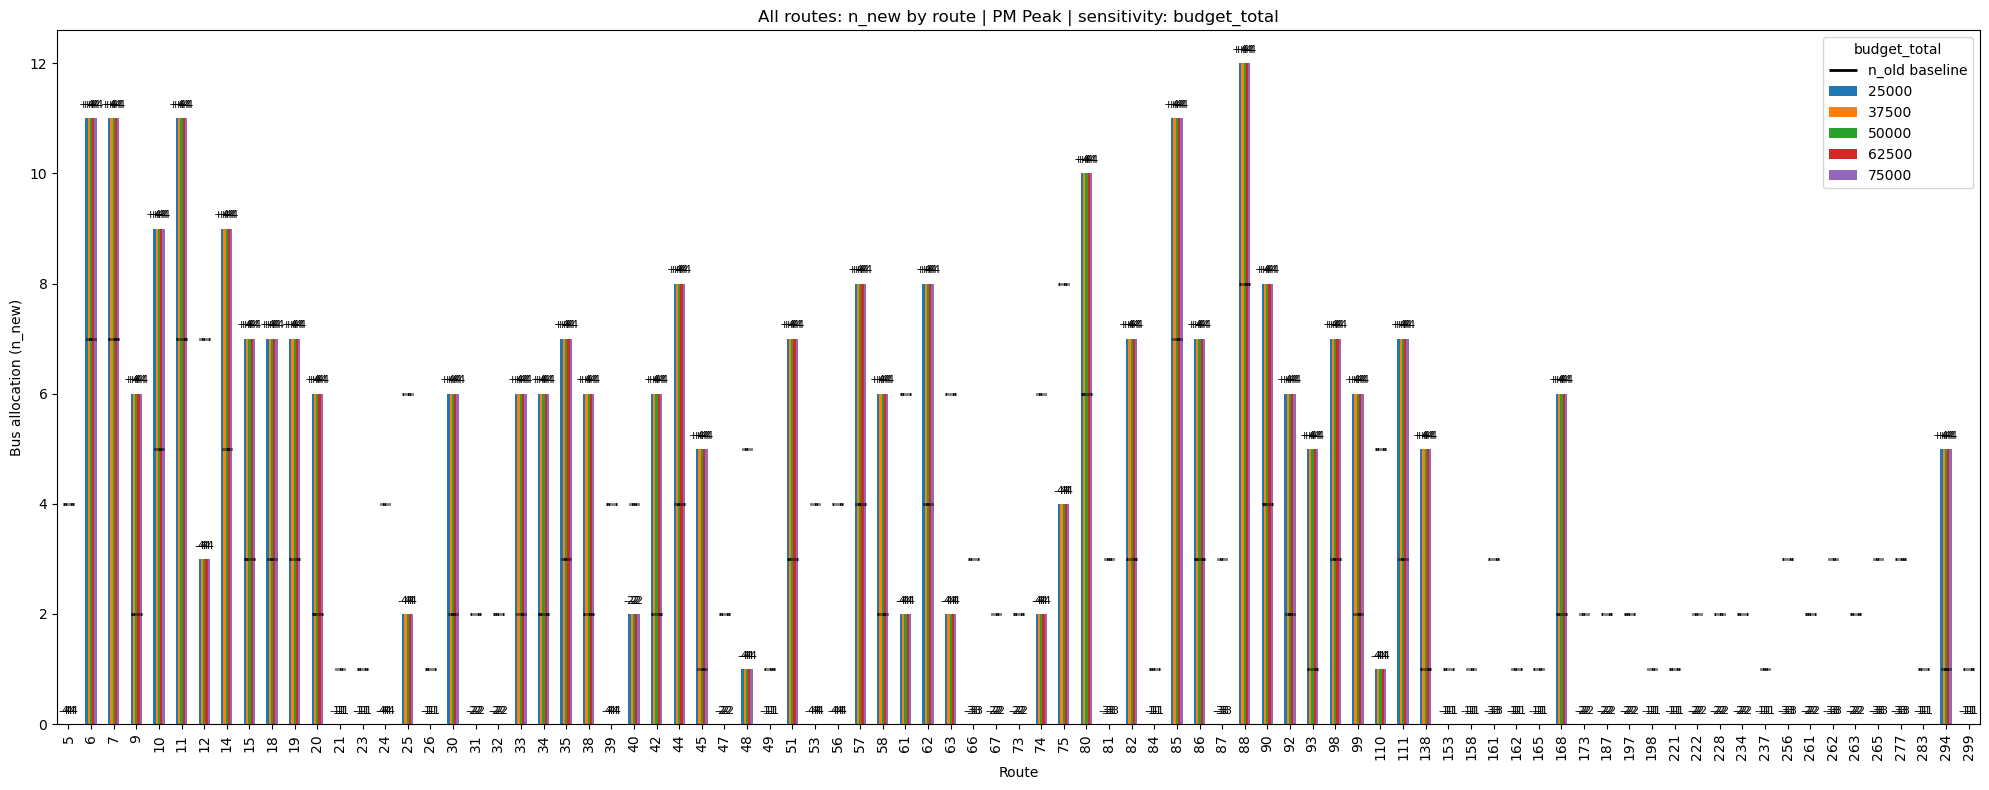

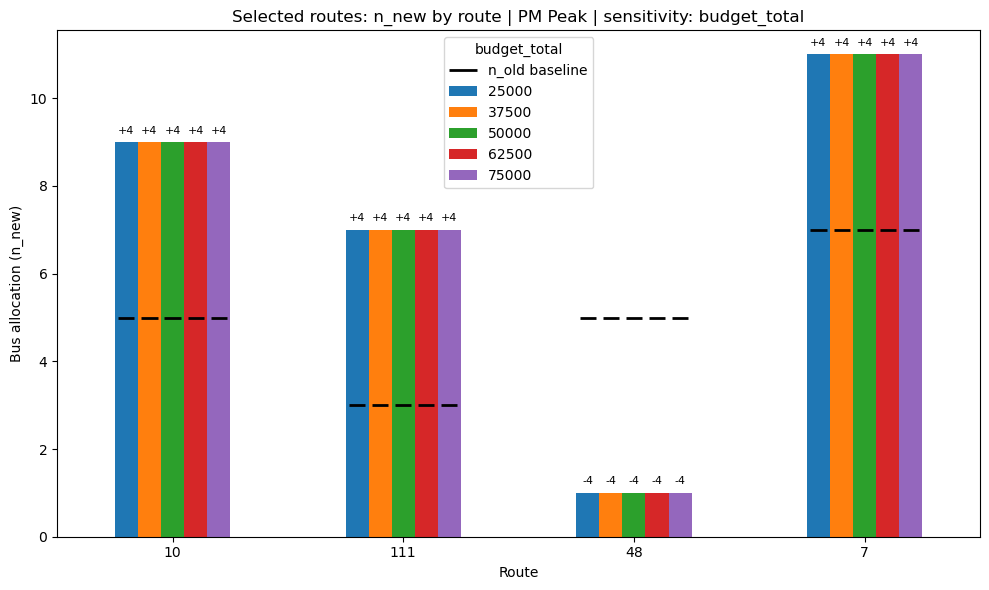

In [36]:
# Plot all routes first, then the smaller routes-of-interest view.
plot_all_routes_bar(
    solution_results=solution_results,
    parameter_name=SENSITIVITY_SETUP['parameter_name'],
    time_block=GRAPH_SETUP['time_block'],
    value_col=GRAPH_SETUP['value_col'],
    sort_routes_numeric=GRAPH_SETUP['sort_routes_numeric'],
    show_baseline_ticks=GRAPH_SETUP['show_baseline_ticks'],
    show_delta_labels=GRAPH_SETUP['show_delta_labels'],
    show_legend_baseline=GRAPH_SETUP['show_legend_baseline'],
    color_bars_by_delta=GRAPH_SETUP['color_bars_by_delta'],
)

plot_selected_routes_bar(
    solution_results=solution_results,
    parameter_name=SENSITIVITY_SETUP['parameter_name'],
    routes_of_interest=ROUTES_OF_INTEREST,
    time_block=GRAPH_SETUP['time_block'],
    value_col=GRAPH_SETUP['value_col'],
    show_baseline_ticks=GRAPH_SETUP['show_baseline_ticks'],
    show_delta_labels=GRAPH_SETUP['show_delta_labels'],
    show_legend_baseline=GRAPH_SETUP['show_legend_baseline'],
    color_bars_by_delta=GRAPH_SETUP['color_bars_by_delta'],
)
